SVM CLASSIFICATION USING IRIS DATASETS

 Dataset Shape: (150, 6)
/n First 5 Rows


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



 Training samples: 120
Testing Samples: 30

 SVM accuracy
96.67%

 Classifictaion Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



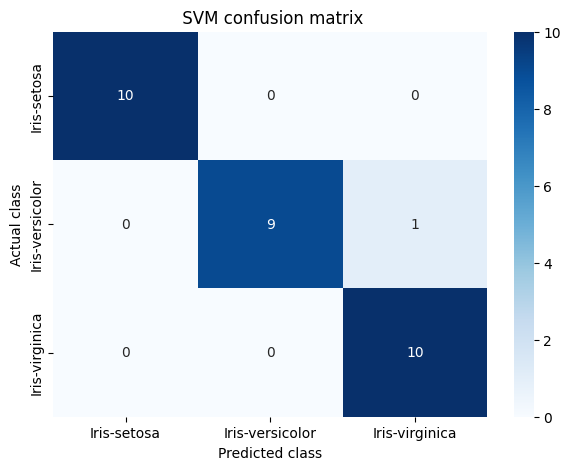

Number of Support Vectors: 47
/n Support Vectors per Class:
[10 18 19]

New Flower:
Sepal Length = 5.1
Sepal Width = 3.5
Petal Length = 1.4
petal Width = 0.2

 Predicted Species: Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


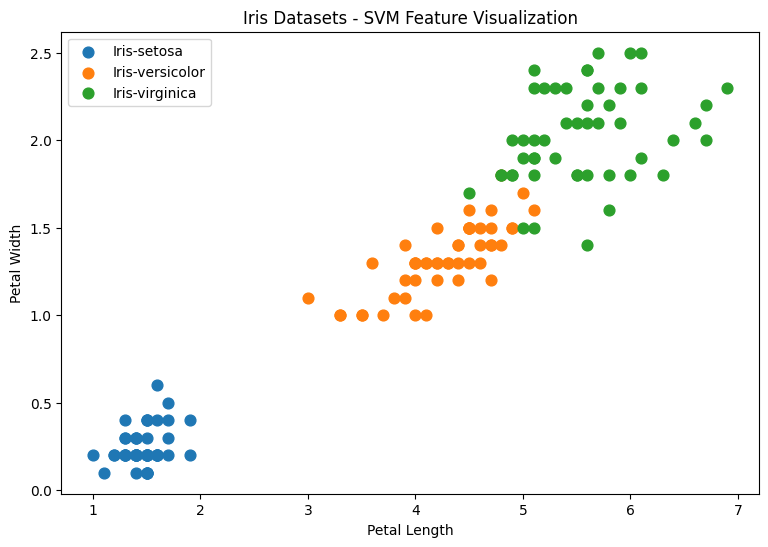


SVM PROJECT COMPLETE SUCCESSFULLY


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
# load datasets
path = "/kaggle/input/datasets/uciml/iris/Iris.csv"
iris = pd.read_csv(path)

print ("="*60)
print("SVM CLASSIFICATION USING IRIS DATASETS")
print ("="*60)
print("\n Dataset Shape:",iris.shape)
print("/n First 5 Rows")
display(iris.head())

#Select features and target
features =[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]
X = iris[features]
y = iris["Species"]

#Train-test split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
)
#feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#create svm model
svm_model = SVC(
    kernel = "rbf",
    C=1.0,
    gamma ="scale",
    probability = True,
    random_state = 42
)
#train model
svm_model.fit(X_train_scaled, y_train)
#
y_pred = svm_model.predict(X_test_scaled)
#accuracy
accuracy = accuracy_score(y_test,y_pred)
print("\n Training samples:",len(X_train))
print("Testing Samples:",len(X_test))
print("\n SVM accuracy")
print(f"{accuracy*100:.2f}%")
#classification report
print("\n Classifictaion Report:")
print(classification_report(y_test,y_pred))
#confusion matrix
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)
plt.title(" SVM confusion matrix")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.show()

print("Number of Support Vectors:",
     len(svm_model.support_))

print("/n Support Vectors per Class:")
print(svm_model.n_support_)
# predict a new flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]
new_flower_scaled = scaler.transform(new_flower)

prediction = svm_model.predict(new_flower_scaled) 

print("\nNew Flower:")
print("Sepal Length = 5.1")
print("Sepal Width = 3.5")
print("Petal Length = 1.4")
print("petal Width = 0.2")
print("\n Predicted Species:", prediction[0])
plt.figure(figsize = (9,6))
for species in iris["Species"].unique():
    data = iris[iris["Species"]== species]
    plt.scatter(
        data["PetalLengthCm"],
        data["PetalWidthCm"],
        s= 60,
        label = species
    )
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Datasets - SVM Feature Visualization")
plt.legend()
plt.show()
print("\n" + "=" *60)
print("SVM PROJECT COMPLETE SUCCESSFULLY")
print("=" *60)

